# Selenium 모듈
![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Selenium_logo.svg/1280px-Selenium_logo.svg.png)
- 웹 어플리케이션 테스트를 위한 프레임 워크
    - 주로, 제작한 홈페이지 테스트 하기 위해 사용
- 다양한 언어 지원 (C++, Java, C#, 파이썬, Ruby, JavaScript, Kotlin 등..). 
- '사용자'가 아닌 '프로그램' 이 **웹 브라우저를 제어**할 수 있도록 지원
    - 웹브라우저 ↔ 프로그램 간 통신 목적
- DOM 구조에 접근 가능 
- 크롤링 보다는 웹을 제어하는 목적이 더 큼   

- 설치(native pip)> **pip instsll selenium**
- 설치(아나콘다) > **conda instsll selenium**

- https://selenium-python.readthedocs.io/   (파이썬 ver.)

- https://www.selenium.dev/  (공식 홈)


In [1]:
from selenium import webdriver

In [2]:
driver = webdriver.Chrome()

# 주소 이동 get(url)

In [3]:
driver.get("http://www.daum.net")

In [4]:
driver.get("http://www.naver.com")

## element 선택

- find_element()  -> element 리턴
- find_elements() -> element 들의 list 리턴
- By.XXX 와 같이 사용됨.|

✅ 체크
- BeautifulSoup 는 응답받은 내용에 대한 파싱
- Selenium 은 브라우저의 DOM 에 대한 검색

### element 의 속성
- .text
- .tag_name
- .get_attribute("attribue name")
- .is_enabled()
- .is_selected()
- .rect    : element 의 x, y , height, width 
- .value_of_css_property('css property')
- https://www.selenium.dev/documentation/en/webdriver/web_element/



In [5]:
from selenium.webdriver.common.by import By

# 무비차트 박스오피스

In [6]:
url = 'https://www.moviechart.co.kr/rank/boxoffice'

In [7]:
driver.get(url)

In [8]:
elements = driver.find_elements(By.CSS_SELECTOR, 'div.listTable table > tbody > tr')

len(elements)

20

In [9]:
element = elements[0]
element

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.13F64CE973E65E12F6837D035D1E24D2.e.121")>

In [10]:
element.text

'01 군체 2026.05.21 79,928 명 4,123,669 명 43,903,753,890 원 예매하기'

In [11]:
title = element.find_element(By.CSS_SELECTOR, 'td.title > a')
title

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.13F64CE973E65E12F6837D035D1E24D2.e.124")>

In [12]:
title.text

'군체'

In [13]:
title.get_attribute('href')

'https://www.moviechart.co.kr/info/movieinfo/detail/20252402'

In [14]:
title.tag_name

'a'

In [15]:
title.rect

{'height': 20, 'width': 26, 'x': 192.5, 'y': 313}

In [16]:
title.value_of_css_property('color')

'rgba(34, 34, 34, 1)'

In [17]:
title.value_of_css_property('text-decoration')

'none'

# 없는 element 를 find_xxx하면

In [18]:
driver.find_elements(By.ID, "xxx")

[]

In [19]:
driver.find_element(By.ID, "xxx")  # NoSuchElementException

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"css selector","selector":"[id="xxx"]"}
  (Session info: chrome=148.0.7778.216); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
0   chromedriver                        0x0000000102964c40 cxxbridge1$str$ptr + 3221216
1   chromedriver                        0x000000010295cb1c cxxbridge1$str$ptr + 3188156
2   chromedriver                        0x000000010241f8f4 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 75152
3   chromedriver                        0x0000000102467ff8 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 371860
4   chromedriver                        0x00000001024a76f4 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 631696
5   chromedriver                        0x000000010245d9c0 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_all

# Selenium 은 response 된 결과가 아닌 

In [20]:
driver.get("http://www.naver.com")

In [21]:
elements= driver.find_elements(By.CSS_SELECTOR, '#newsstand > div[class^="ContentHeaderSubView"] > div[class^="ContentHeaderSubView"] > div')
print(len(elements), "개")

for e in elements:
    print(e.text)

1 개
젠슨 황 "한국에 깜짝 놀랄 선물 준비…투자 관심사는 로봇공학"


# 스크린샷

In [22]:
png_data = driver.get_screenshot_as_png()  # 스크린샷을 png 바이너리로 리턴

In [23]:
from IPython.display import Image

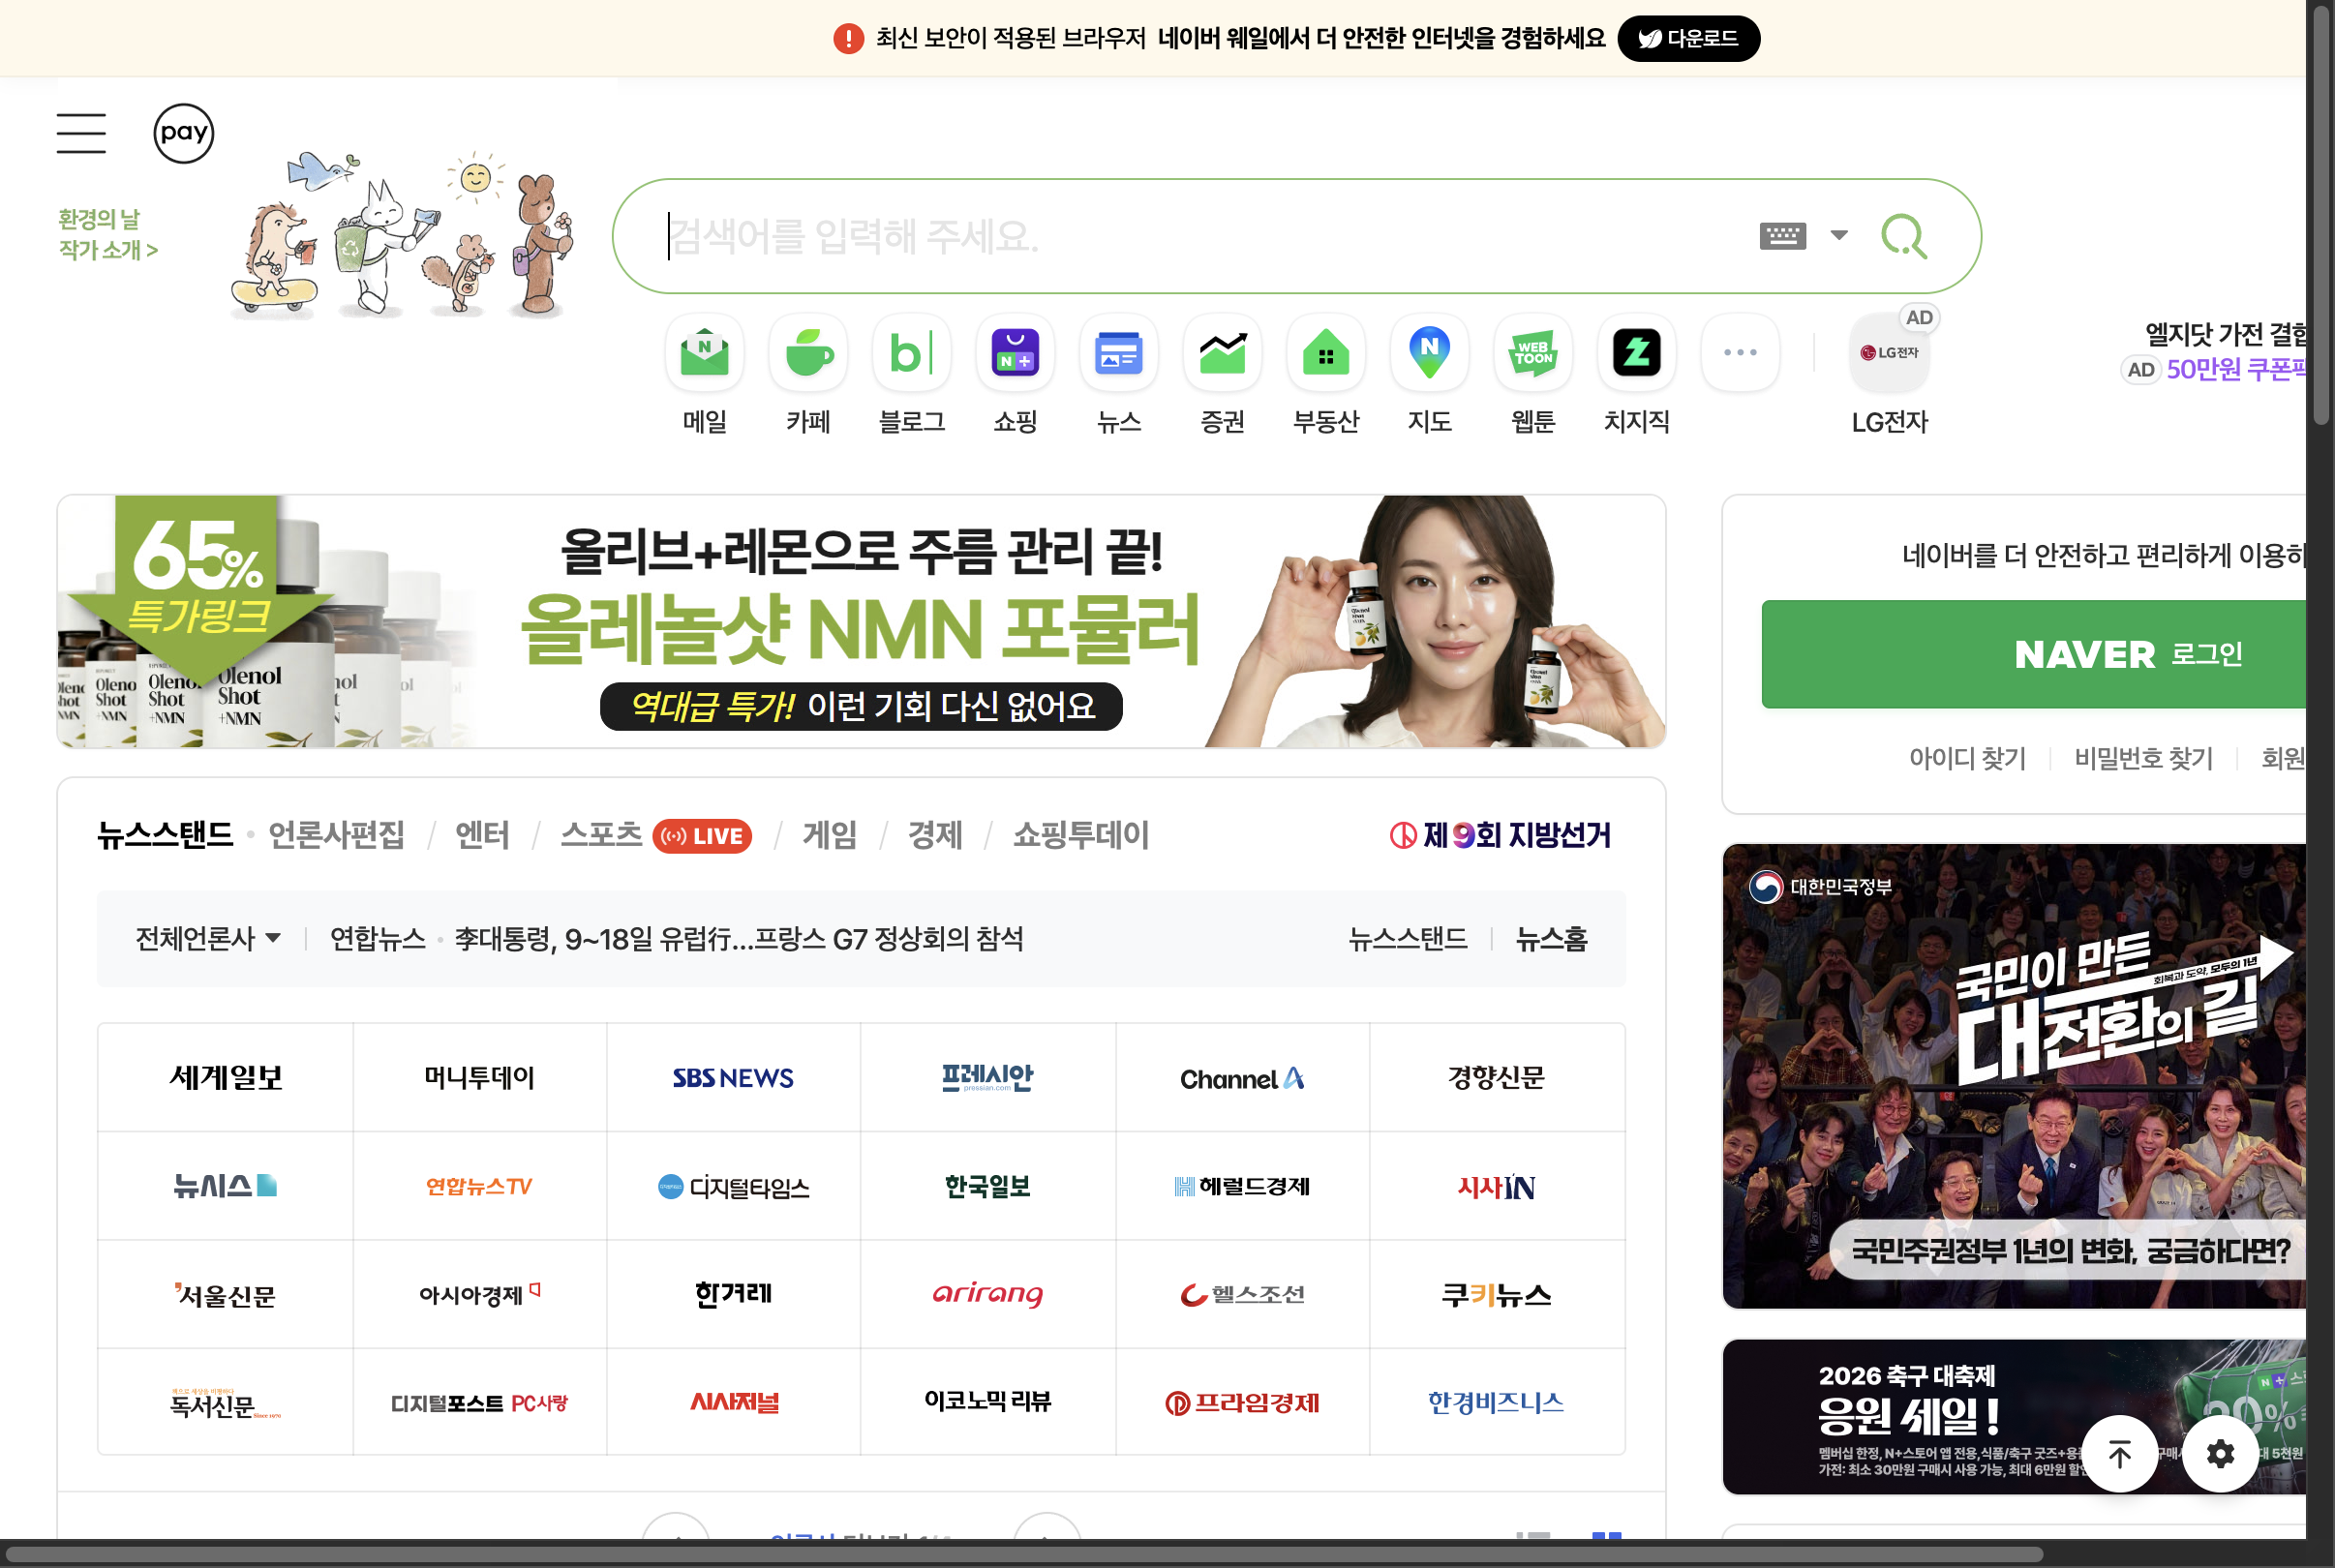

In [24]:
Image(png_data)

In [25]:
import os
img_path = os.path.join('out', 'screenshot_test.png')
driver.get_screenshot_as_file(img_path)

True

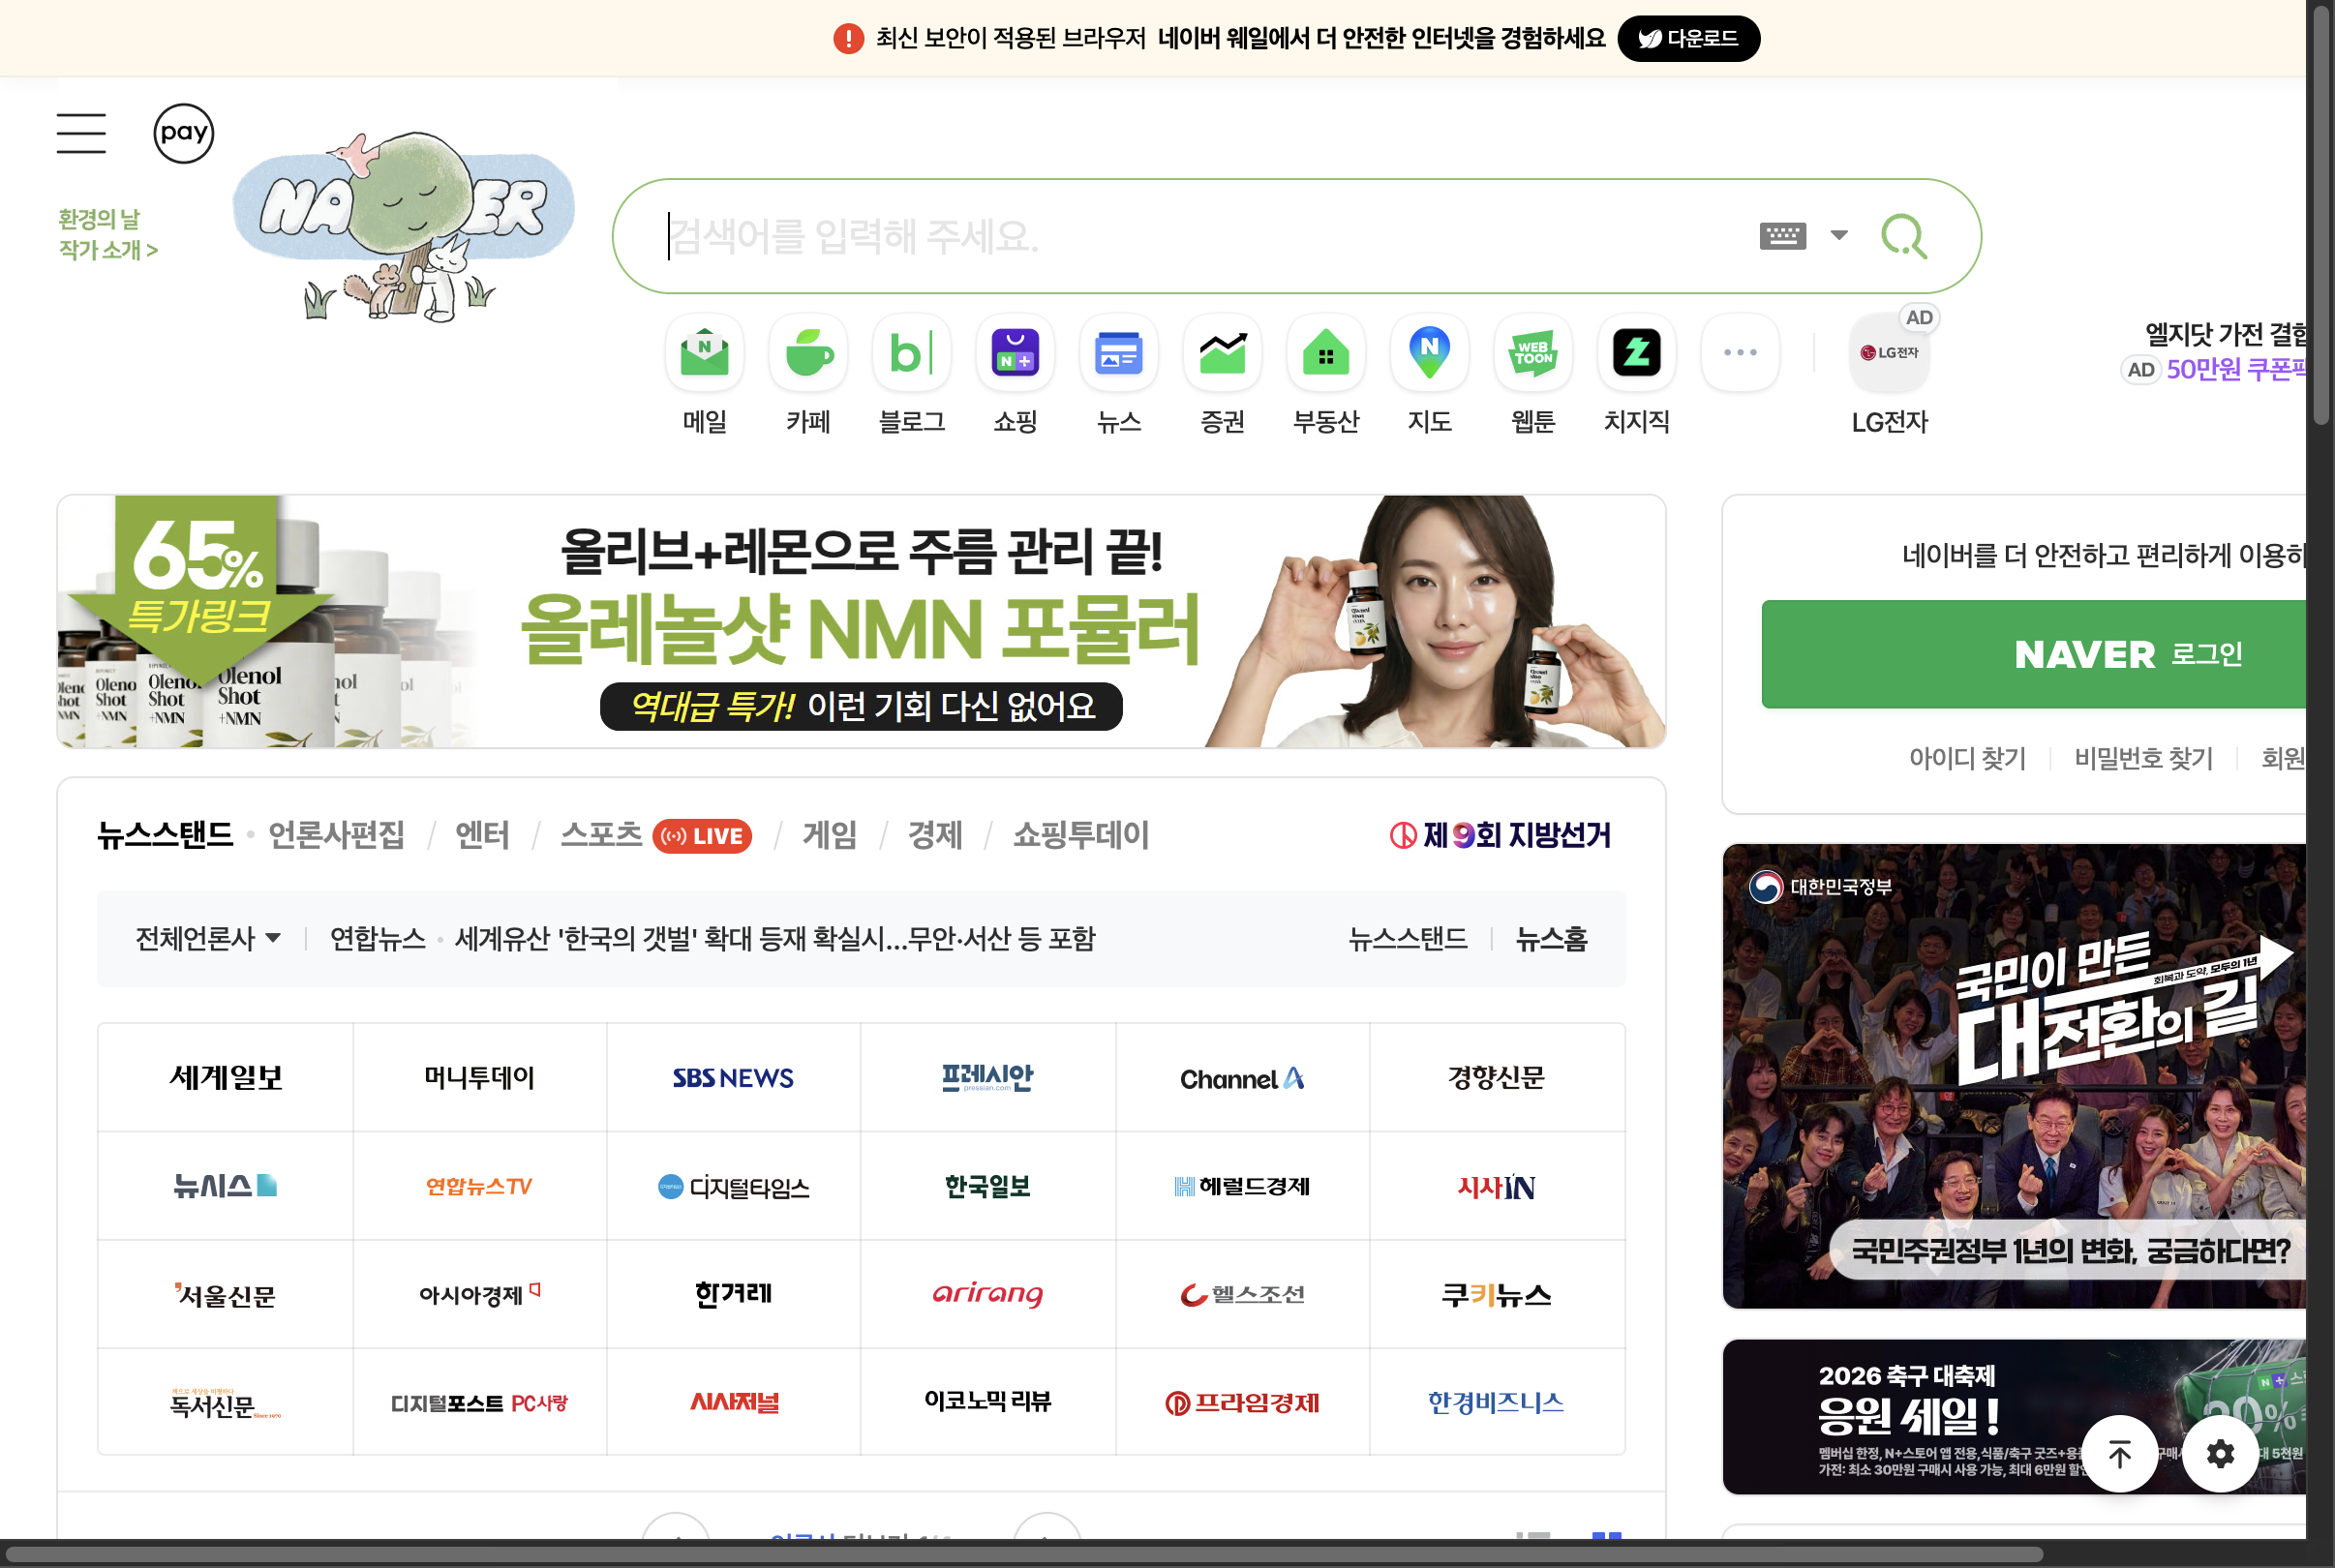

In [26]:
Image(img_path)

# By

In [27]:
driver.find_element(By.ID, 'special-logo')   # id="special-logo"

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.266A1B2B9A4A92BE93B1C1A8C1832377.e.115")>

In [28]:
driver.find_element(By.CLASS_NAME, 'search_special_bg')  # class="search_special_bg"

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.266A1B2B9A4A92BE93B1C1A8C1832377.e.115")>

In [29]:
elements = driver.find_elements(By.TAG_NAME, 'div')
len(elements)

274

## 이벤트 제어, 사용자 입력
- 마우스 클릭 : click()
- 키보드 입력 : send_keys()
- 입력글자지우기 : clear()
- 자바스크립트 실행 :  execute_script()
- 입력양식 전송 : submit()
- 스크린샷 : screenshot(파일명)
- 뒤로가기 : back()
- 앞으로가기 : forward()
- focus 이동  iframe 에 사용 : .switch_to_frame(element)   

In [30]:
input_element = driver.find_element(By.NAME, 'query')   # name='query'
input_element 

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.266A1B2B9A4A92BE93B1C1A8C1832377.e.42")>

In [31]:
input_element.send_keys('김정준')

In [32]:
from selenium.webdriver.common.keys import Keys

In [33]:
input_element.send_keys(Keys.ENTER)

In [34]:
input_element = driver.find_element(By.NAME, 'query')
input_element 

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.0998FEDE4D40C36F46A84DA464BB8169.e.2876")>

In [35]:
input_element.clear()

In [36]:
input_element.send_keys('문태현')

In [37]:
search_form = driver.find_element(By.NAME, 'search')
search_form

<selenium.webdriver.remote.webelement.WebElement (session="22b58ad6803085076eeb1666b055d136", element="f.E9A509E296DFD2D306FDE11ADA94ADE9.d.0998FEDE4D40C36F46A84DA464BB8169.e.2869")>

In [38]:
# form element 의 경우 submit() 으로 제출 가능.
#  단! JS로 form submit 를 가로채는 이벤트 등록되어 있다면
#  정상가동 하지 않을수도 있다
search_form.submit()

In [ ]:
input_element = driver.find_element(By.NAME, 'query')
input_element 

In [ ]:
input_element.clear()
input_element.send_keys('장희준')

In [ ]:
# JavaScript 코드 실행
driver.execute_script("""
    document.getElementById("nx_search_form").submit()
""")

In [ ]:
input_element = driver.find_element(By.NAME, 'query')
input_element.clear()
input_element.send_keys('권용현')

In [ ]:
search_form = driver.find_element(By.ID, "nx_search_form")
search_form

In [ ]:
# JavaScript 코드 실행
driver.execute_script("arguments[0].submit()", search_form)

# 페이지 소스

In [ ]:
driver.page_source[:200]

### selenium 은 실제 브라우저 제어 동작
- 인증후 접근해야 하는 페이지 등에서 사용 가능.
- 상대적으로 로딩이 많이 걸리는 단점
- 많은 작업을 한번에 처리하는 경우 처리 속도를 따라오지 못함.
    - 아직 url 페이지 로딩도 안되었는데, find_xx_() 가 실행될수도 있다.
- 그래서, sleep() 나 WebDriverWait 객체 활용해야 한다

### 특수키 입력
- from selenium.webdriver.common.keys import Keys
- **Keys.특수키**   로 사용 가능<br>
    ARROW_DOWN, ARROW_LEFT, ARROW_RIGHT, ARROW_UP<br>
    BACKSPACE, DELETE, HOME, END, INSERT, ALT, COMMAND, CONTROL, SHIFT, ENTER,<br>
    ESCAPE, SPACE, TAB, F1, F2 ... F12
    
    - https://www.w3.org/TR/webdriver/#keyboard-actions <- WebDriver 가 지원하는 키입력들

## requests 와 selenium  모듈 사용
- requests 모듈 단점 : 로그인이나 어떤 사용자 조작후의 정보들은 가져오기 어렵다
- selenium 단점 : 수많은 데이터를 손쉽게 가져오기 어렵다 (느리고, 메모리 많이 잡아먹음)

- 접근하기 어려운 페이지를 selenium 으로 접근한뒤 BS4 로 파싱한다!

